In [ ]:
!unzip dataset-resized.zip -d .


Archive:  dataset-resized.zip
   creating: ./dataset-resized/
  inflating: ./dataset-resized/.DS_Store  
   creating: ./__MACOSX/
   creating: ./__MACOSX/dataset-resized/
  inflating: ./__MACOSX/dataset-resized/._.DS_Store  
   creating: ./dataset-resized/cardboard/
  inflating: ./dataset-resized/cardboard/cardboard1.jpg  
  inflating: ./dataset-resized/cardboard/cardboard10.jpg  
  inflating: ./dataset-resized/cardboard/cardboard100.jpg  
  inflating: ./dataset-resized/cardboard/cardboard101.jpg  
  inflating: ./dataset-resized/cardboard/cardboard102.jpg  
  inflating: ./dataset-resized/cardboard/cardboard103.jpg  
  inflating: ./dataset-resized/cardboard/cardboard104.jpg  
  inflating: ./dataset-resized/cardboard/cardboard105.jpg  
  inflating: ./dataset-resized/cardboard/cardboard106.jpg  
  inflating: ./dataset-resized/cardboard/cardboard107.jpg  
  inflating: ./dataset-resized/cardboard/cardboard108.jpg  
  inflating: ./dataset-resized/cardboard/cardboard109.jpg  
  inflating: ./d

In [ ]:
import os

base_dir = "dataset-resized"
for root, dirs, files in os.walk(base_dir):
    print(root, "->", len(files), "files")


dataset-resized -> 1 files
dataset-resized/plastic -> 482 files
dataset-resized/metal -> 410 files
dataset-resized/glass -> 501 files
dataset-resized/cardboard -> 403 files
dataset-resized/trash -> 137 files
dataset-resized/paper -> 594 files


In [ ]:
import tensorflow as tf

img_height, img_width = 224, 224
batch_size = 32

# Load datasets WITHOUT any mapping yet
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset-resized",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset-resized",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Access class names now
class_names = raw_train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)

# Now apply normalization and performance optimizations
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = raw_train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = raw_val_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.2470 - loss: 2.3197 - val_accuracy: 0.3505 - val_loss: 1.4916
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 312s 4s/step - accuracy: 0.4170 - loss: 1.4585 - val_accuracy: 0.4376 - val_loss: 1.3215
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.5006 - loss: 1.2754 - val_accuracy: 0.5168 - val_loss: 1.1891
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.5755 - loss: 1.1008 - val_accuracy: 0.5446 - val_loss: 1.1168
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 254s 4s/step - accuracy: 0.6448 - loss: 0.9236 - val_accuracy: 0.5683 - val_loss: 1.1375
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 243s 4s/step - accuracy: 0.7085 - loss: 0.7934 - val_accuracy: 0.6218 - val_loss: 1.0990
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 242s 4s/step - accuracy: 0.8141 - loss: 0.5878 - val_accuracy: 0.5960 - val_loss: 1.1911
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.8392 - loss: 0.4746 - val_accuracy: 0.6257 - v

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {test_acc:.2f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6288 - loss: 1.9493
Validation Accuracy: 0.62


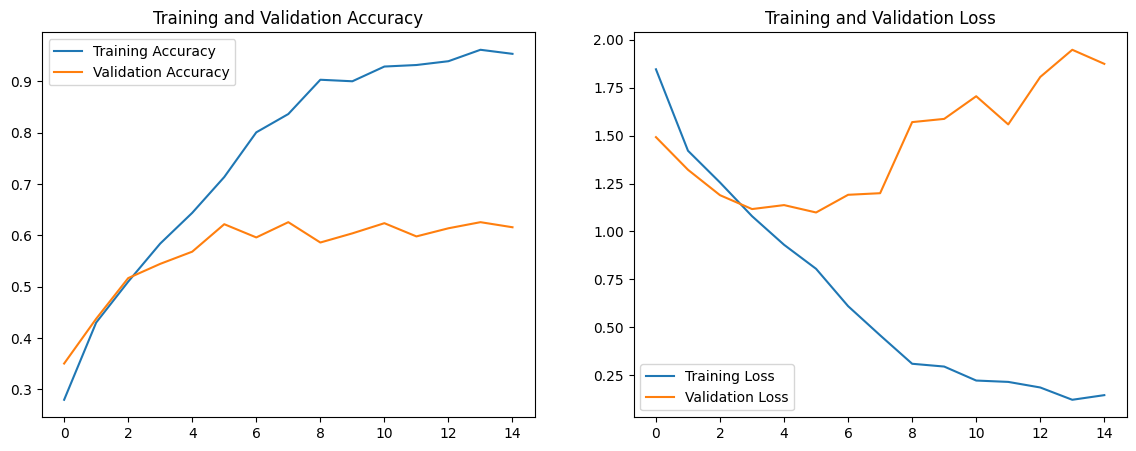

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()
